
🔍 Missing Values in Each Column:


,Missing Values
Pregnancies,48
Glucose,37
BloodPressure,27
SkinThickness,23
Insulin,49
BMI,37
DiabetesPedigreeFunction,37
Age,32
Outcome,45


<Figure size 1200x800 with 0 Axes>

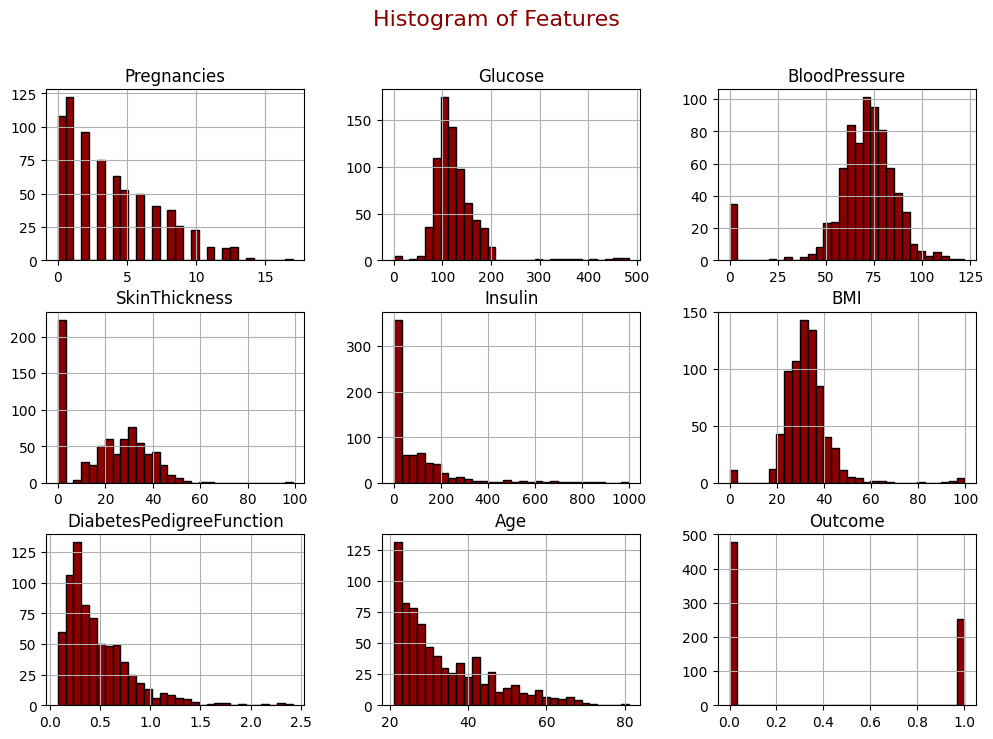

<Figure size 1200x1200 with 0 Axes>

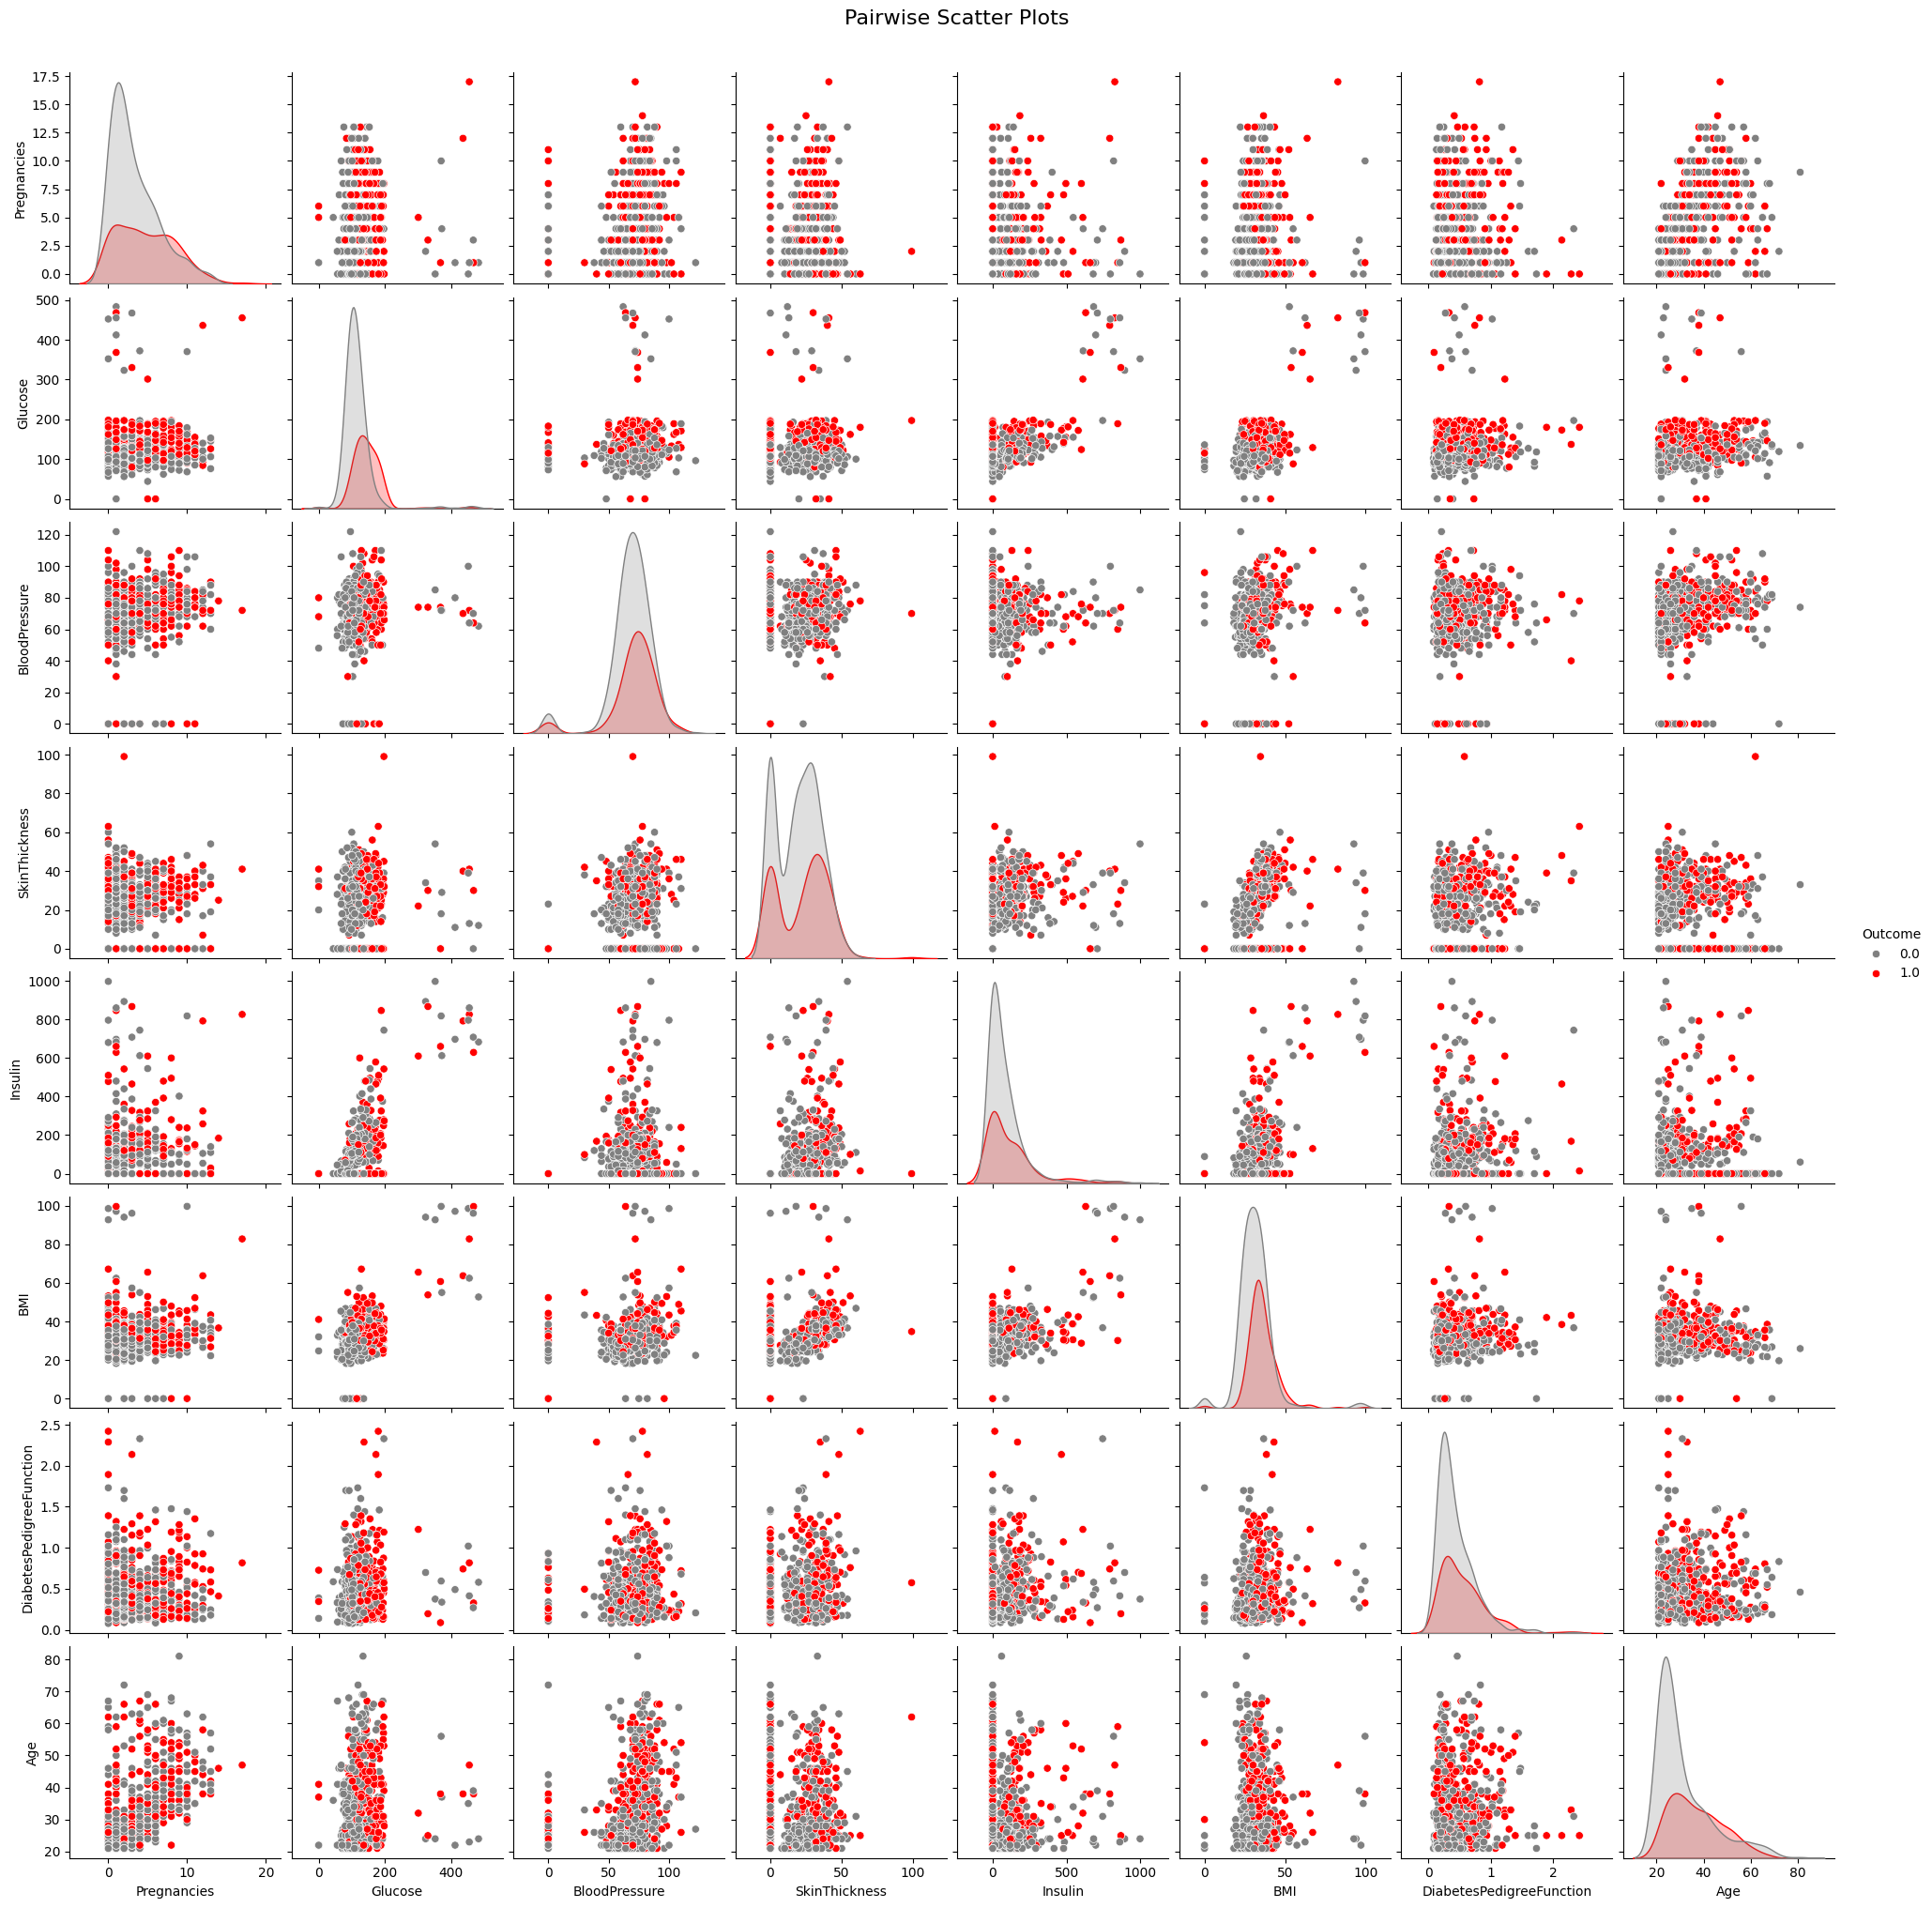

<ipython-input-54-abb1cb00e21f>:38: UserWarning: 
The palette list has fewer values (2) than needed (9) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df, palette=["grey", "red"])


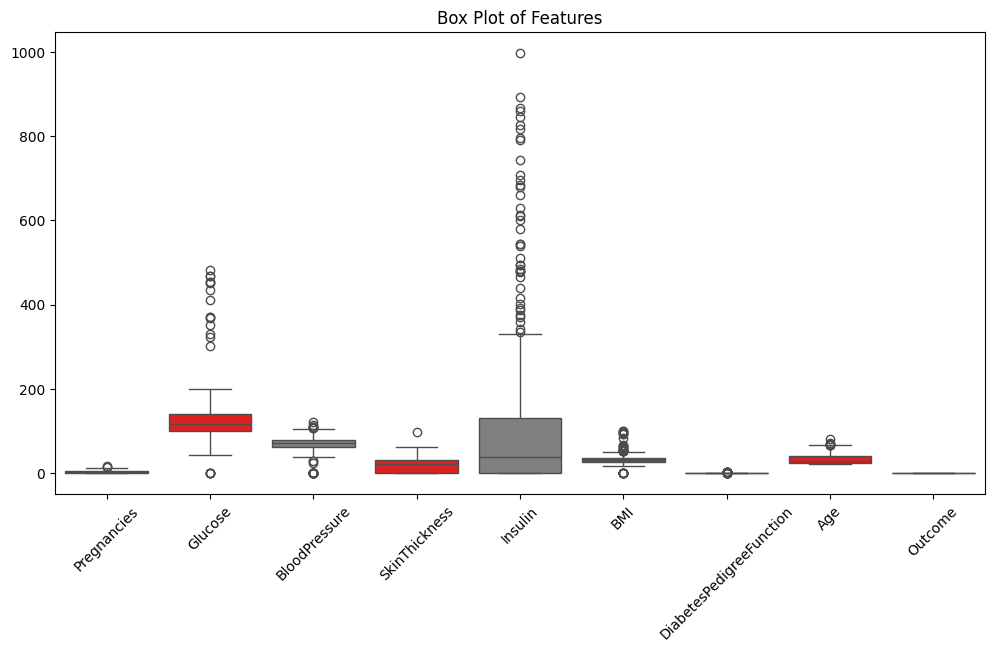

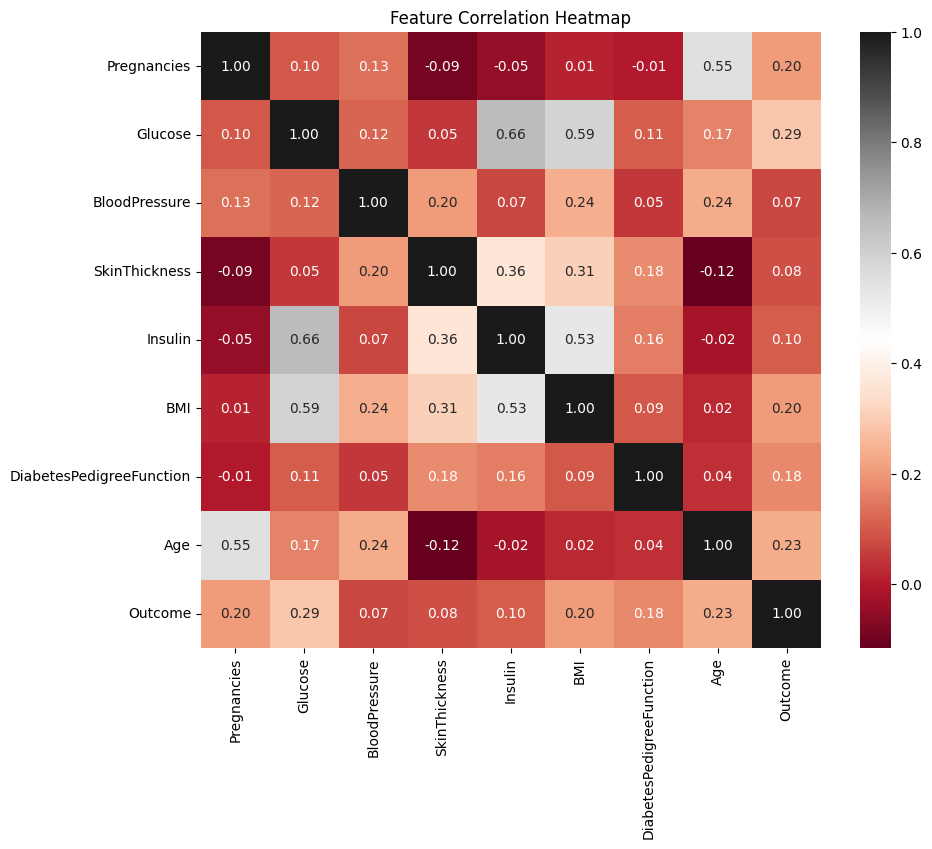


 Missing Values After Preprocessing (Imputation):


,Missing Values After Imputation
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


Original dataset shape: (775, 9)
Dataset shape after removing outliers: (618, 9)

 First 7 Rows After Robust Scaling:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.6,0.977778,0.000,0.37500,-0.340909,0.146341,0.801282,1.423729,1.0
1,-0.4,-0.888889,-0.375,0.18750,-0.340909,-0.707317,-0.083333,0.135593,0.0
2,1.0,2.014815,-0.500,-0.71875,-0.340909,-1.109756,0.945513,0.203390,1.0
3,-0.4,-0.770370,-0.375,0.00000,0.513636,-0.524390,-0.673077,-0.542373,0.0
4,0.0,0.029630,0.125,-0.71875,-0.340909,-0.829268,-0.564103,0.067797,0.0
5,0.0,-1.096296,-1.375,0.28125,0.000000,-0.170732,-0.413462,-0.203390,1.0
6,0.2,-0.148148,1.250,-0.71875,-0.340909,0.634146,-0.596154,0.067797,0.0


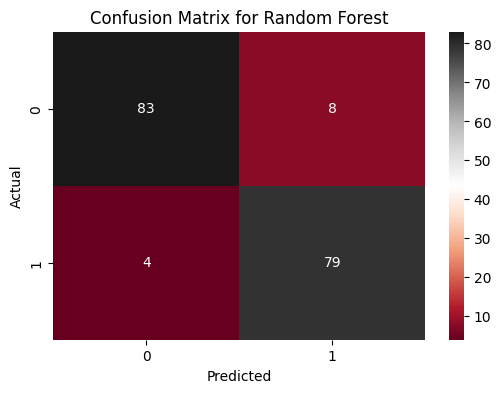

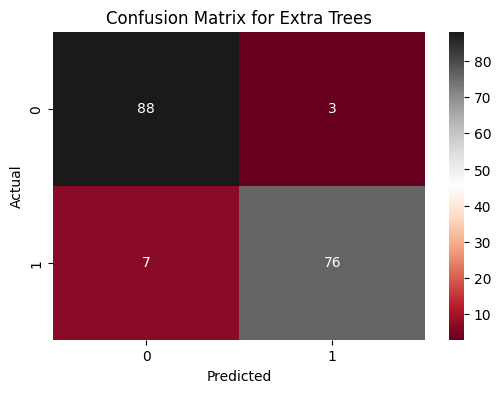

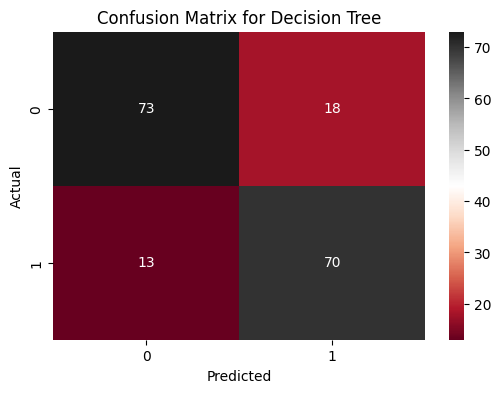

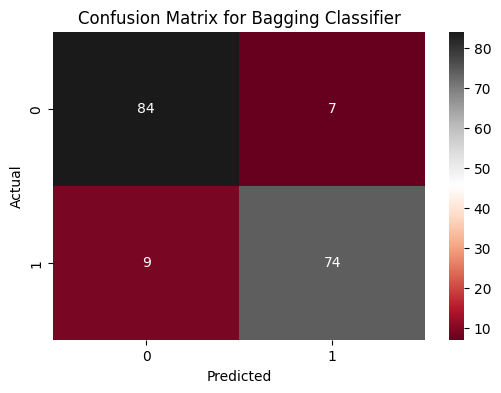

<ipython-input-54-abb1cb00e21f>:146: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([0, 1], [0, 1], 'k--', color='grey')


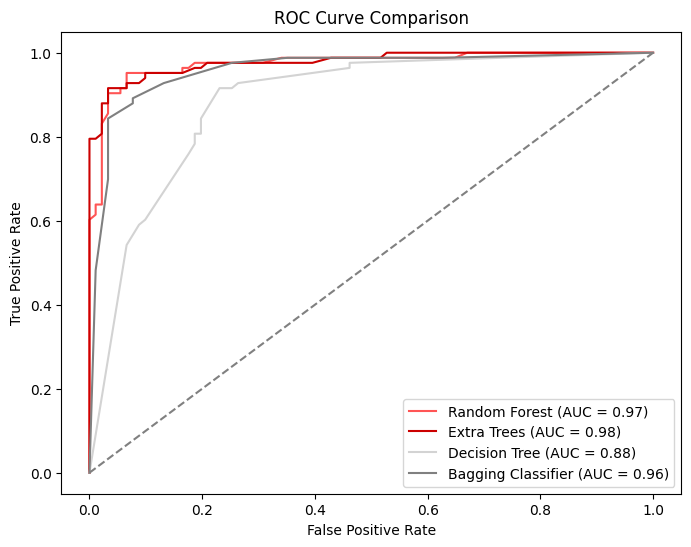


📊 Model Performance Metrics:


,Training Accuracy,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Random Forest,1.0000,0.9310,0.9080,0.9518,0.9294,0.9741
Extra Trees,1.0000,0.9425,0.9620,0.9157,0.9383,0.9781
Decision Tree,0.8736,0.8218,0.7955,0.8434,0.8187,0.8849
Bagging Classifier,0.9928,0.9080,0.9136,0.8916,0.9024,0.9584


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc
from imblearn.over_sampling import RandomOverSampler
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Load dataset
df = pd.read_csv('diabetes_DATASET_.csv')

# Check for missing values
missing_values = pd.DataFrame(df.isnull().sum(), columns=['Missing Values'])
print("\n🔍 Missing Values in Each Column:")
display(missing_values)

# Histogram: Distribution of Variables
plt.figure(figsize=(12, 8))
df.hist(bins=30, figsize=(12, 8), color='darkred', edgecolor='black')
plt.suptitle("Histogram of Features", fontsize=16, color='darkred')
plt.show()

# Pairwise Scatter Plots
plt.figure(figsize=(12, 12))
sns.pairplot(df, hue="Outcome", palette=["grey", "red"], diag_kind="kde")
plt.suptitle("Pairwise Scatter Plots", fontsize=16, y=1.02)
plt.show()

# Box Plot: Detect Outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, palette=["grey", "red"])
plt.xticks(rotation=45)
plt.title("Box Plot of Features")
plt.show()

# Heatmap: Feature Correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='RdGy', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

# Handle missing values by replacing with the median
df_imputed = df.fillna(df.median())

# Check for missing values after preprocessing
missing_values_after_imputation = pd.DataFrame(df_imputed.isnull().sum(), columns=['Missing Values After Imputation'])
print("\n Missing Values After Preprocessing (Imputation):")
display(missing_values_after_imputation)

# Remove outliers using IQR
Q1 = df_imputed.quantile(0.25)
Q3 = df_imputed.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df_no_outliers = df_imputed[~((df_imputed < lower_bound) | (df_imputed > upper_bound)).any(axis=1)]
df_no_outliers.reset_index(drop=True, inplace=True)

# Print dataset shape before & after removing outliers
print(f"Original dataset shape: {df.shape}")
print(f"Dataset shape after removing outliers: {df_no_outliers.shape}")

# Scale features
scaler = RobustScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_no_outliers), columns=df_no_outliers.columns)

# Print first 7 rows after scaling
print("\n First 7 Rows After Robust Scaling:")
display(df_scaled.head(7))

# Separate features and target
X = df_scaled.drop('Outcome', axis=1)
y = df_scaled['Outcome'].astype(int)

# Handle class imbalance with oversampling
ros = RandomOverSampler(random_state=42)
X_balanced, y_balanced = ros.fit_resample(X, y)

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, random_state=1)

# Define models with regularization and early stopping
models = {
    "Random Forest": RandomForestClassifier(),
    "Extra Trees": ExtraTreesClassifier(),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, min_samples_split=10, min_samples_leaf=5, random_state=1),
    "Bagging Classifier": BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=1)
}

results = {}

# Train and evaluate models
for name, model in models.items():
    # Train model
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

    # Calculate training accuracy
    train_accuracy = accuracy_score(y_train, model.predict(X_train))

    # Store results
    results[name] = {
        "Training Accuracy": train_accuracy,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    }

# Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdGy')
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Plot ROC Curve
plt.figure(figsize=(8, 6))
colors = ['#FF5555', '#CC0000', '#D3D3D3', '#808080', '#FF6347', '#228B22', '#4169E1']

for i, (name, model) in enumerate(models.items()):
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})', color=colors[i])

plt.plot([0, 1], [0, 1], 'k--', color='grey')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.show()

# Display performance metrics
results_df = pd.DataFrame(results).T.round(4)
print("\n📊 Model Performance Metrics:")
display(results_df)
